In [7]:
import pandas as pd
import numpy as np
import json
import json
import pandas as pd
import matplotlib.pyplot as plt

class MeanRevStrategy:
    def __init__(self, price_data):
        self.price_data = price_data  # DataFrame with timestamp indexed asset prices
        self.leverage = 50
        self.initial_portfolio_value = 2000

    def calculate_zscore(self, spread_series, window):
        mean = spread_series.rolling(window=window).mean()
        std = spread_series.rolling(window=window).std()
        z_score = (spread_series - mean) / std
        return z_score

    def simulate_trade(self, market, POSITION_SIZE, Z_SCORE_LONG, Z_SCORE_SHORT, window):
        spread_series = self.price_data[market]
        z_score_series = self.calculate_zscore(spread_series, window)

        # Initialize portfolio values tracking
        portfolio_value = self.initial_portfolio_value
        in_position = False
        position_type = None  # Track whether the position is long or short

        for idx in range(len(self.price_data)):
            current_z_score = z_score_series.iloc[idx]
            current_price = spread_series.iloc[idx]
            trade_return = 0.0

            # Flipping positions based on Z_SCORE threshold
            if in_position:
                # Calculate return based on price change since entry
                price_increase = (current_price - entry_price) * ((POSITION_SIZE * self.leverage) / entry_price)
                if position_type == "long" and current_z_score >= Z_SCORE_SHORT:
                    trade_return = price_increase - (POSITION_SIZE * self.leverage) * 0.02
                    in_position, position_type, entry_price = False, None, None
                elif position_type == "short" and current_z_score <= -Z_SCORE_LONG:
                    in_position, position_type, entry_price = False, None, None
                    trade_return = -price_increase - (POSITION_SIZE * self.leverage) * 0.02
            elif not in_position:
                if current_z_score <= -Z_SCORE_LONG:  # Enter long position
                    in_position, position_type, entry_price = True, "long", current_price
                elif current_z_score >= Z_SCORE_SHORT:  # Enter short position
                   in_position, position_type, entry_price = True, "short", current_price

            portfolio_value += trade_return

        # Exiting the last open position at the end of the data
        if in_position:
            # Simulate exiting the position with no additional profit or loss
            in_position, position_type = False, None

        # Returning the portfolio values for further analysis
        return portfolio_value

    def run_monte_carlo_simulation(self, iterations, window_range, z_score_long_range, z_score_short_range, output_name):
        simulation_results = []

        for _ in range(iterations):
            WINDOW = np.random.randint(*window_range)
            POSITION_SIZE = 1
            Z_SCORE_LONG = np.random.uniform(*z_score_long_range)
            Z_SCORE_SHORT = np.random.uniform(*z_score_short_range)
            total_returns = self.trade_all_markets(WINDOW, POSITION_SIZE, Z_SCORE_LONG, Z_SCORE_SHORT)
            simulation_results.append({
                'returns': total_returns,
                'window': WINDOW,
                'position_size': POSITION_SIZE,
                'z_score_long': Z_SCORE_LONG,
                'z_score_short': Z_SCORE_SHORT
            })

        # Save all simulation results to a JSON file
        with open(f'{output_name}_simulation_results.json', 'w') as f:
            json.dump(simulation_results, f, indent=4)

        return simulation_results

    def trade_all_markets(self, WINDOW, POSITION_SIZE, Z_SCORE_LONG, Z_SCORE_SHORT):
        total_returns = 0.0
        for market in self.price_data.columns:
            if market == 'time':
                continue

            portfolio_value = self.simulate_trade(market, POSITION_SIZE, Z_SCORE_LONG, Z_SCORE_SHORT, WINDOW)
            returns = portfolio_value - self.initial_portfolio_value
            total_returns += returns

        return total_returns

# Example usage:
# Assuming you have a DataFrame `df` with a 'time' column and market price columns
# strategy = MeanRevStrategy(df)
# simulation_results = strategy.run_monte_carlo_simulation(iterations=1000)

In [12]:
data_15m_final = pd.read_csv('data_final_15m.csv').tail(7000)

strategy_final_15 = MeanRevStrategy(data_15m_final)
params_15m = strategy_final_15.run_monte_carlo_simulation(1000, (100, 800), (1.5, 4.5), (2.5, 7), '15m_final_7000_ls')

In [13]:
# Load the simulation results
with open('15m_final_7000_ls_simulation_results.json', 'r') as f:
    simulation_results_15m_final = json.load(f)

# Convert the results to a DataFrame
df = pd.DataFrame(simulation_results_15m_final)

# Sort the DataFrame by the 'Score' column in descending order
sorted_df = df.sort_values(by='returns', ascending=False)

sorted_df.head(10)

,returns,window,position_size,z_score_long,z_score_short
813,884.695614,142,1,1.657178,4.894072
841,878.175699,163,1,1.933390,5.121666
275,857.895657,106,1,1.550141,4.747356
711,841.036276,144,1,2.167101,5.008551
56,819.149791,120,1,2.427000,4.632269
439,798.998597,106,1,1.821884,4.383417
183,772.883999,198,1,2.409609,4.733398
614,756.252937,212,1,2.297726,5.638748
609,702.631693,216,1,1.674649,5.356457
796,676.686446,308,1,1.500844,5.426631


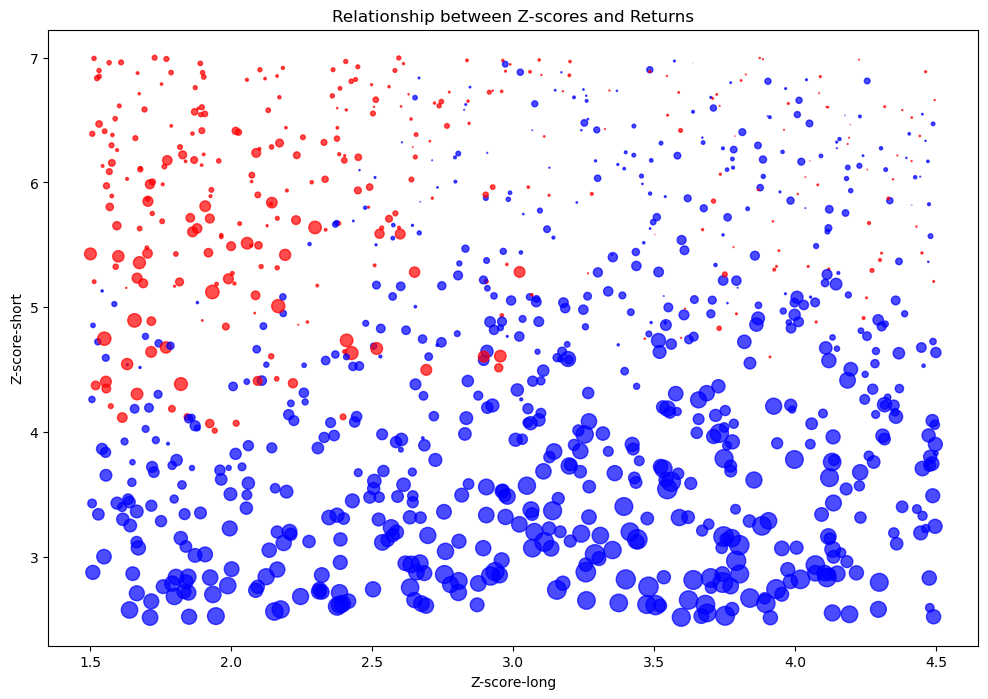

In [19]:
# Load the simulation results
with open('15m_final_7000_ls_simulation_results.json', 'r') as f:
    simulation_results_15m_final = json.load(f)

# Convert the results to a DataFrame
df = pd.DataFrame(simulation_results_15m_final)

# Create a column for colors (red for positive, blue for negative)
df['color'] = df['returns'].apply(lambda x: 'red' if x > 0 else 'blue')

# Create a column for size based on the absolute value of returns
df['size'] = df['returns'].abs() / df['returns'].abs().max() * 200  # Normalize sizes to range [0, 200]

# Create the scatter plot
plt.figure(figsize=(12, 8))
scatter_plot = plt.scatter(
    x=df['z_score_long'],
    y=df['z_score_short'],
    c=df['color'],  # Use the 'color' column for point colors
    s=df['size'],   # Use the 'size' column for point sizes
    alpha=0.7       # Add transparency for better visualization
)

# Add labels and title
plt.title('Relationship between Z-scores and Returns')
plt.xlabel('Z-score-long')
plt.ylabel('Z-score-short')

plt.show()

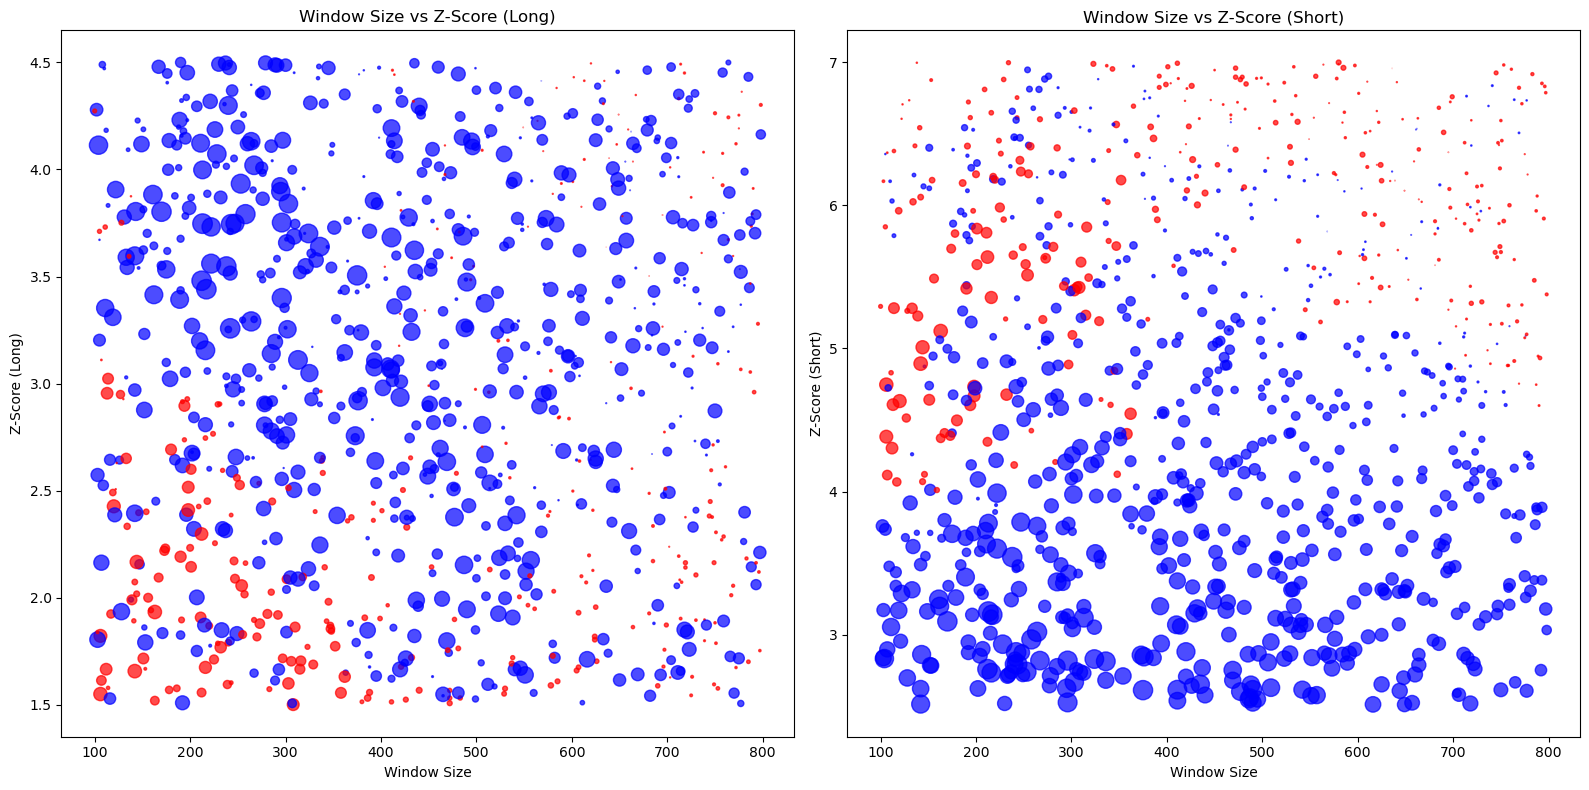

In [15]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # 1 row, 2 columns

# First scatter plot
scatter_plot1 = axes[0].scatter(
    x=df['window'],
    y=df['z_score_long'],
    c=df['color'],  # Use the 'color' column for point colors
    s=df['size'],   # Use the 'size' column for point sizes
    alpha=0.7       # Add transparency for better visualization
)
axes[0].set_title('Window Size vs Z-Score (Long)')
axes[0].set_xlabel('Window Size')
axes[0].set_ylabel('Z-Score (Long)')

# Second scatter plot
scatter_plot2 = axes[1].scatter(
    x=df['window'],
    y=df['z_score_short'],
    c=df['color'],  # Use the 'color' column for point colors
    s=df['size'],   # Use the 'size' column for point sizes
    alpha=0.7       # Add transparency for better visualization
)
axes[1].set_title('Window Size vs Z-Score (Short)')
axes[1].set_xlabel('Window Size')
axes[1].set_ylabel('Z-Score (Short)')

# Adjust spacing between plots
plt.tight_layout()

# Show the plots
plt.show()


In [18]:
data_15m_final = pd.read_csv('data_final_15m.csv').tail(7000)

strategy_final_15 = MeanRevStrategy(data_15m_final)
params_15m = strategy_final_15.run_monte_carlo_simulation(1000, (100, 400), (1.5, 3.0), (4.0, 7.0), '15m_final_7000_ls_tight')

In [21]:
# Load the simulation results
with open('15m_final_7000_ls_tight_simulation_results.json', 'r') as f:
    simulation_results_15m_final = json.load(f)

# Convert the results to a DataFrame
df = pd.DataFrame(simulation_results_15m_final)

# Sort the DataFrame by the 'Score' column in descending order
sorted_df = df.sort_values(by='returns', ascending=False)

sorted_df.head(10)

,returns,window,position_size,z_score_long,z_score_short
206,937.734273,117,1,2.355340,4.929957
229,931.649482,102,1,2.410125,5.021734
511,930.832738,145,1,1.857093,4.917628
190,909.173382,122,1,2.381779,4.802233
185,893.934632,128,1,2.130167,4.837387
536,890.971843,142,1,1.810611,4.907662
567,882.816308,162,1,1.592644,5.126711
889,882.291728,121,1,2.240219,4.894630
786,876.243706,131,1,2.093132,4.760358
281,875.164337,114,1,1.819218,4.872921


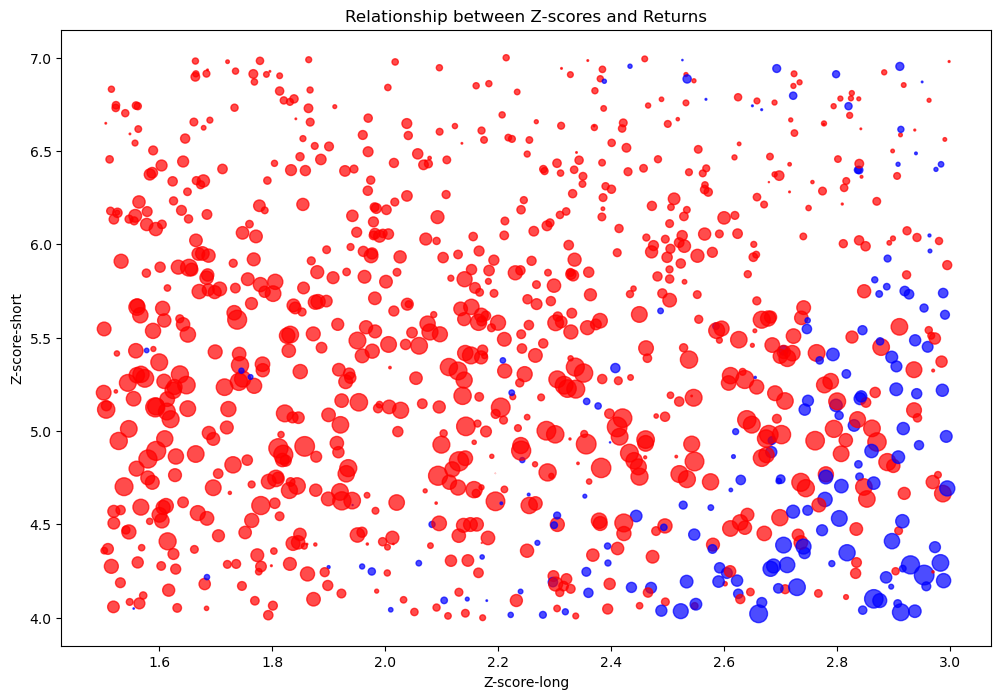

In [26]:
# Load the simulation results
with open('15m_final_7000_ls_tight_simulation_results.json', 'r') as f:
    simulation_results_15m_final = json.load(f)

# Convert the results to a DataFrame
df = pd.DataFrame(simulation_results_15m_final)

# Create a column for colors (red for positive, blue for negative)
df['color'] = df['returns'].apply(lambda x: 'red' if x > 0 else 'blue')

# Create a column for size based on the absolute value of returns
df['size'] = df['returns'].abs() / df['returns'].abs().max() * 200  # Normalize sizes to range [0, 200]

# Create the scatter plot
plt.figure(figsize=(12, 8))
scatter_plot = plt.scatter(
    x=df['z_score_long'],
    y=df['z_score_short'],
    c=df['color'],  # Use the 'color' column for point colors
    s=df['size'],   # Use the 'size' column for point sizes
    alpha=0.7       # Add transparency for better visualization
)

# Add labels and title
plt.title('Relationship between Z-scores and Returns')
plt.xlabel('Z-score-long')
plt.ylabel('Z-score-short')

plt.show()

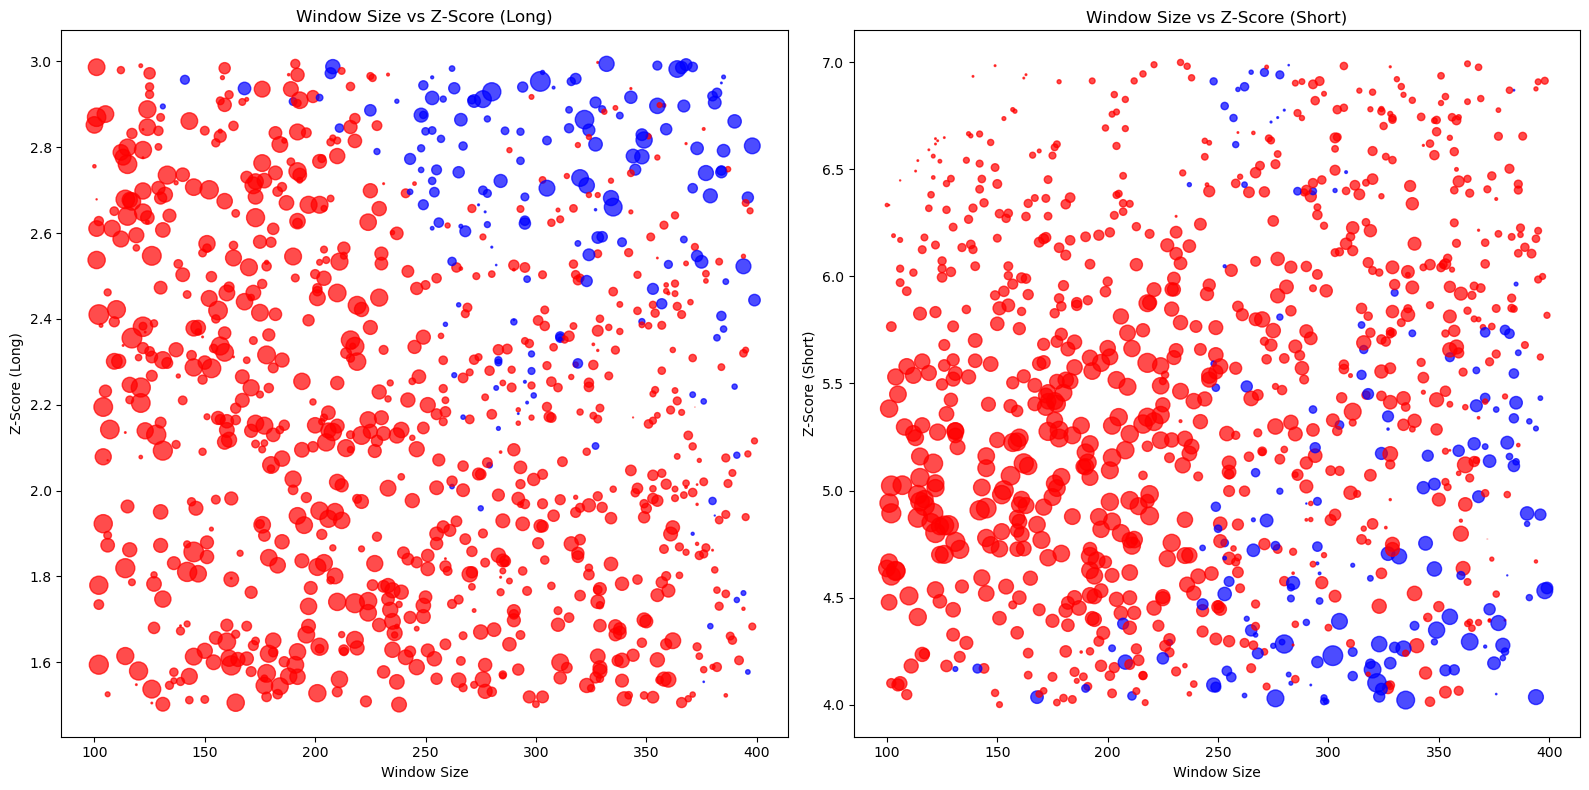

In [27]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # 1 row, 2 columns

# First scatter plot
scatter_plot1 = axes[0].scatter(
    x=df['window'],
    y=df['z_score_long'],
    c=df['color'],  # Use the 'color' column for point colors
    s=df['size'],   # Use the 'size' column for point sizes
    alpha=0.7       # Add transparency for better visualization
)
axes[0].set_title('Window Size vs Z-Score (Long)')
axes[0].set_xlabel('Window Size')
axes[0].set_ylabel('Z-Score (Long)')

# Second scatter plot
scatter_plot2 = axes[1].scatter(
    x=df['window'],
    y=df['z_score_short'],
    c=df['color'],  # Use the 'color' column for point colors
    s=df['size'],   # Use the 'size' column for point sizes
    alpha=0.7       # Add transparency for better visualization
)
axes[1].set_title('Window Size vs Z-Score (Short)')
axes[1].set_xlabel('Window Size')
axes[1].set_ylabel('Z-Score (Short)')

# Adjust spacing between plots
plt.tight_layout()

# Show the plots
plt.show()

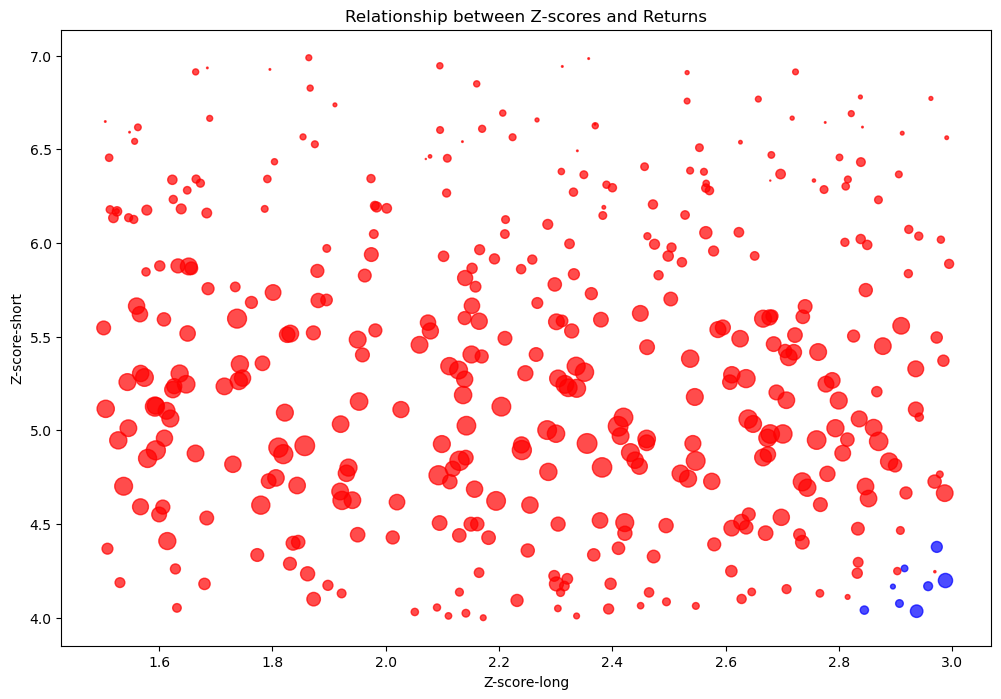

In [28]:
filtered_df = df[df['window']< 225]

# Create the scatter plot
plt.figure(figsize=(12, 8))
scatter_plot = plt.scatter(
    x=filtered_df['z_score_long'],
    y=filtered_df['z_score_short'],
    c=filtered_df['color'],  # Use the 'color' column for point colors
    s=filtered_df['size'],   # Use the 'size' column for point sizes
    alpha=0.7       # Add transparency for better visualization
)

# Add labels and title
plt.title('Relationship between Z-scores and Returns')
plt.xlabel('Z-score-long')
plt.ylabel('Z-score-short')

plt.show()

In [29]:
# Sort the DataFrame by the 'Score' column in descending order
sorted_df = filtered_df.sort_values(by='returns', ascending=False)

sorted_df.head(30)

,returns,window,position_size,z_score_long,z_score_short,color,size
206,937.734273,117,1,2.355340,4.929957,red,200.000000
229,931.649482,102,1,2.410125,5.021734,red,198.702236
511,930.832738,145,1,1.857093,4.917628,red,198.528040
190,909.173382,122,1,2.381779,4.802233,red,193.908532
185,893.934632,128,1,2.130167,4.837387,red,190.658411
536,890.971843,142,1,1.810611,4.907662,red,190.026507
567,882.816308,162,1,1.592644,5.126711,red,188.287094
889,882.291728,121,1,2.240219,4.894630,red,188.175212
786,876.243706,131,1,2.093132,4.760358,red,186.885290
281,875.164337,114,1,1.819218,4.872921,red,186.655082


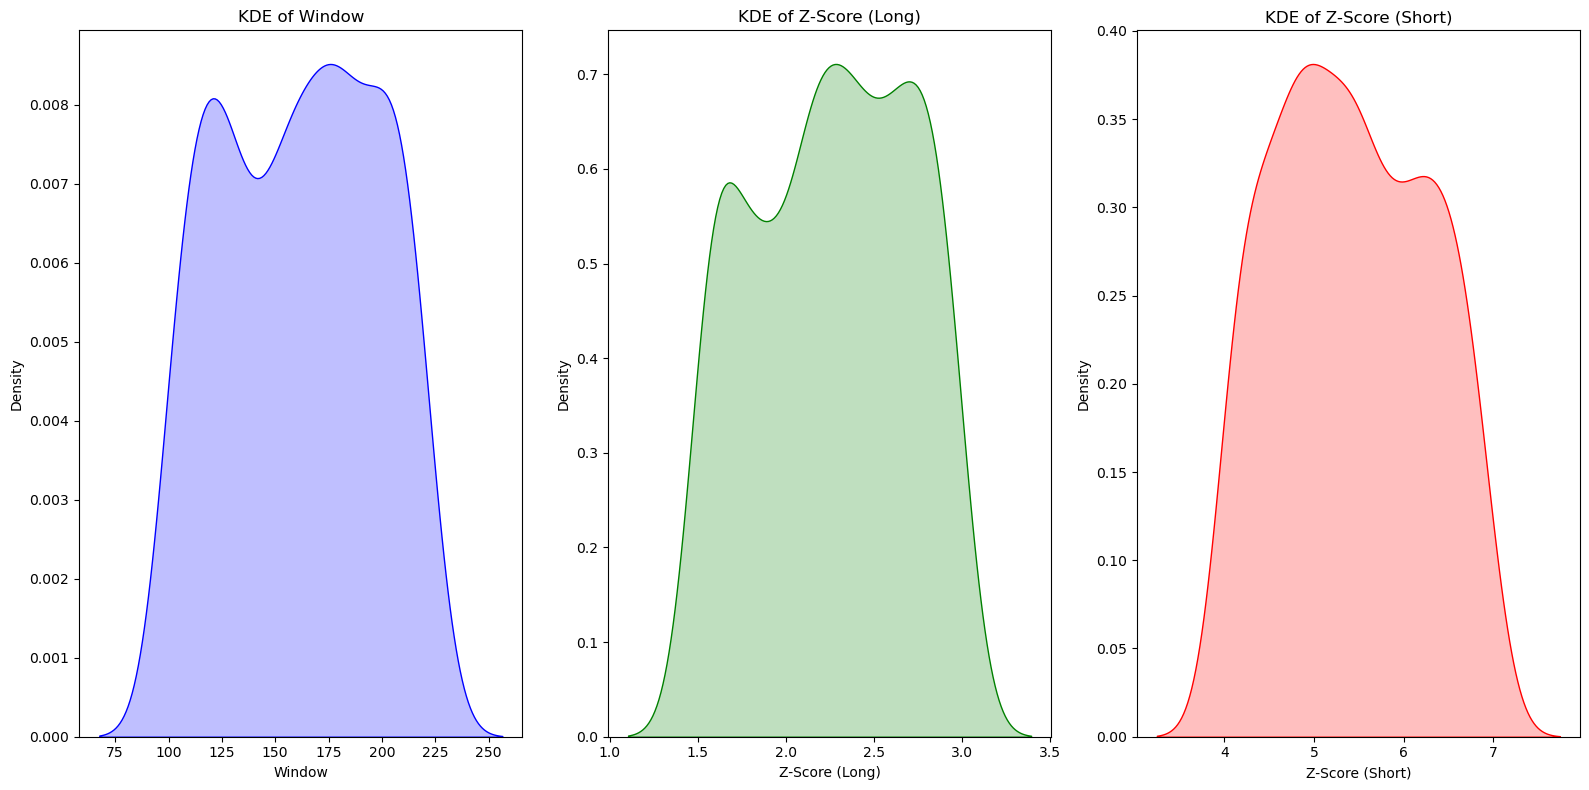

In [30]:
import seaborn as sns

# Create a figure with three KDE plots
plt.figure(figsize=(16, 8))

# KDE for 'window'
plt.subplot(1, 3, 1)
sns.kdeplot(sorted_df['window'], fill=True, color='blue')
plt.title('KDE of Window')
plt.xlabel('Window')
plt.ylabel('Density')

# KDE for 'z_score_long'
plt.subplot(1, 3, 2)
sns.kdeplot(sorted_df['z_score_long'], fill=True, color='green')
plt.title('KDE of Z-Score (Long)')
plt.xlabel('Z-Score (Long)')
plt.ylabel('Density')

# KDE for 'z_score_short'
plt.subplot(1, 3, 3)
sns.kdeplot(sorted_df['z_score_short'], fill=True, color='red')
plt.title('KDE of Z-Score (Short)')
plt.xlabel('Z-Score (Short)')
plt.ylabel('Density')

# Adjust spacing
plt.tight_layout()
plt.show()

Window 160

z_score_long 2.3

z_score_short 5.0